###Objectives of the Analysis
Find the most popular projects: See which GitHub repositories have the highest number of stars to know what developers like most.

Track growth over time: Look at creation dates by year to see when most projects were created and how trends changed.

Help make better choices: Use the data to decide whether to create a new project or use existing ones.

##Task 1 Build the Data Collection Pipeline

In [ ]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
!pip install ipython-sql==0.5.0 prettytable==3.9.0

In [ ]:
%load_ext sql
%config SqlMagic.style = "PLAIN_COLUMNS"
%sql sqlite:///github_data.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


###Step 1: Collect API Data

In [ ]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

In [ ]:
response = requests.get(url)

In [ ]:
response.status_code

200

In [ ]:
print("The first record in each column")
data = response.json()
data["items"][0]

The first record in each column


{'id': 45717250,
 'node_id': 'MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==',
 'name': 'tensorflow',
 'full_name': 'tensorflow/tensorflow',
 'private': False,
 'owner': {'login': 'tensorflow',
  'id': 15658638,
  'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE1NjU4NjM4',
  'avatar_url': 'https://avatars.githubusercontent.com/u/15658638?v=4',
  'gravatar_id': '',
  'url': 'https://api.github.com/users/tensorflow',
  'html_url': 'https://github.com/tensorflow',
  'followers_url': 'https://api.github.com/users/tensorflow/followers',
  'following_url': 'https://api.github.com/users/tensorflow/following{/other_user}',
  'gists_url': 'https://api.github.com/users/tensorflow/gists{/gist_id}',
  'starred_url': 'https://api.github.com/users/tensorflow/starred{/owner}{/repo}',
  'subscriptions_url': 'https://api.github.com/users/tensorflow/subscriptions',
  'organizations_url': 'https://api.github.com/users/tensorflow/orgs',
  'repos_url': 'https://api.github.com/users/tensorflow/repos',
  'events_url': 'https://api.git

###Step 2: Create the Dataset
Converting the dataset into a Pandas DataFrame, To make the data easier to work with.

In [ ]:
df = pd.DataFrame(data["items"])

In [ ]:
print("These are the first five rows of teh dataframe")
df.head()

These are the first five rows of teh dataframe


,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76115,2947,197375,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34334,2409,164374,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22044,13,89716,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15274,52,82621,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15621,26,74132,master,1.0


#### Exploring the dataset information and number of rows and columns and the columns names

In [ ]:
print("The dataset information")
df.info()

The dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-nul

In [ ]:
print("The number of rows and columns")
df.shape

The number of rows and columns


(100, 82)

In [ ]:
print("These are the columns names")
df.columns

These are the columns names


Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

###Step 3: Select Required Columns
select only the columns required for analysis:
name, owner , language , stargazers_count , forks_count , watchers_count , open_issues_count , created_at , updated_at , license

In [ ]:
required_columns = ["name",
                    "owner",
                    "language",
                    "stargazers_count",
                    "forks_count",
                    "watchers_count",
                    "open_issues_count",
                    "created_at",
                    "updated_at",
                    "license"]

In [ ]:
df = df[required_columns]

The owner and license columns are kept because they contain useful information that will be extracted in the next step.

In [ ]:
print("The first five rows in the focused and organized dataframe")
df.head()

The first five rows in the focused and organized dataframe


,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197375,76115,197375,2947,2015-11-07T01:19:20Z,2026-08-23T21:07:14Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164374,34334,164374,2409,2018-10-29T13:56:00Z,2026-08-23T22:28:42Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89716,22044,89716,13,2021-03-03T01:34:05Z,2026-08-23T23:12:27Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82621,15274,82621,52,2018-08-21T11:20:39Z,2026-08-23T20:09:35Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74132,15621,74132,26,2014-07-15T19:11:19Z,2026-08-23T21:58:31Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


###Step 4: Extract Required Values
Some information returned by the GitHub API is stored as nested data, so Instead of keeping the complete nested objects, you will extract only the values needed for the project. This makes the dataset simpler, clearer, and easier to analyze.

In [ ]:
df["owner"] = df["owner"].str.get("login")


In [ ]:
df["license"] = df["license"].str.get("name")

In [ ]:
print("The first five rows of the extracted data")
df.head()

The first five rows of the extracted data


,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07T01:19:20Z,2026-08-23T21:07:14Z,Apache License 2.0
1,transformers,huggingface,Python,164374,34334,164374,2409,2018-10-29T13:56:00Z,2026-08-23T22:28:42Z,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89716,22044,89716,13,2021-03-03T01:34:05Z,2026-08-23T23:12:27Z,MIT License
3,funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21T11:20:39Z,2026-08-23T20:09:35Z,None
4,awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15T19:11:19Z,2026-08-23T21:58:31Z,Other


###Step 5: Handle Missing Values
Handling missing values improves the quality and reliability of the dataset and helps reduce the risk of inaccurate results during analysis.

In [ ]:
print("The number of missing values before handling")
df.isnull().sum()

The number of missing values before handling


,0
name,0
owner,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,22


In [ ]:
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("Unknown")

In [ ]:
print("The number of missing values after handling")
df.isnull().sum()

The number of missing values after handling


,0
name,0
owner,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
license,0


###Step 6: Handle Duplicate Records
Checking the dataset for duplicate records and remove unnecessary duplicates while preserving the correct information.

In [ ]:
print("The number of duplicated values before handling")
df.duplicated().sum()

The number of duplicated values before handling


np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
print("The number of duplicated values after handling")
df.duplicated().sum()

The number of duplicated values after handling


np.int64(0)

###Step 7: Prepare the Dataset


In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["updated_at"] = pd.to_datetime(df["updated_at"])

In [ ]:
df = df.rename(columns = {"stargazers_count": "stars",
                          "forks_count": "forks",
                          "watchers_count": "watchers",
                          "open_issues_count": "open_issues",
                          "created_at": "created_date",
                          "updated_at": "updated_date"})

In [ ]:
print("The fisrt five rows of the dataframe after cleaning and handling")
df.head()

The fisrt five rows of the dataframe after cleaning and handling


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
1,transformers,huggingface,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89716,22044,89716,13,2021-03-03 01:34:05+00:00,2026-08-23 23:12:27+00:00,MIT License
3,funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,Other


The created_at and updated_at columns are converted into an appropriate date format.
This makes it easier to work with dates and identify trends over time.
Next, several column names will be shortened to make them clearer and easier to use in SQL queries:

In [ ]:
df.to_csv("github_projects.csv", index = False)
print("Dataset successfully saved as 'github_projects.csv'")

Dataset successfully saved as 'github_projects.csv'


In [ ]:
df_prepared = pd.read_csv("github_projects.csv")
print("The first five rows of the reloaded dataset")
df_prepared.head()

The first five rows of the reloaded dataset


,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
1,transformers,huggingface,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89716,22044,89716,13,2021-03-03 01:34:05+00:00,2026-08-23 23:12:27+00:00,MIT License
3,funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,Unknown
4,awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,Other


##Task 2 – Store and Analyze the Data

###Step 1: Create the SQLite Database

In [ ]:
con = sqlite3.connect("github_data.db")
df_prepared.to_sql("Repositories", con, if_exists="replace", index=False)

100

Checking that the connection goes well

In [ ]:
%%sql
SELECT *
FROM Repositories
Limit 5;

 * sqlite:///github_data.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
transformers,huggingface,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89716,22044,89716,13,2021-03-03 01:34:05+00:00,2026-08-23 23:12:27+00:00,MIT License
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,Unknown
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,Other


###Step 2: Filtering & Searching Queries


In [ ]:
%%sql
SELECT *
FROM Repositories
WHERE stars > 10000

 * sqlite:///github_data.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
transformers,huggingface,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89716,22044,89716,13,2021-03-03 01:34:05+00:00,2026-08-23 23:12:27+00:00,MIT License
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,Unknown
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,Other
scikit-learn,scikit-learn,Python,67036,27305,67036,2127,2010-08-17 09:43:38+00:00,2026-08-23 23:18:23+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,Unknown
C-Plus-Plus,TheAlgorithms,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,MIT License
netron,lutzroeder,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,MIT License


In [ ]:
%%sql
SELECT *
FROM Repositories
WHERE name LIKE "%Machine%";

 * sqlite:///github_data.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,Other
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,Unknown
machine-learning-for-software-engineers,ZuzooVn,Unknown,28869,6147,28869,32,2016-10-09 21:20:25+00:00,2026-08-23 19:47:14+00:00,Creative Commons Attribution Share Alike 4.0 International
homemade-machine-learning,trekhleb,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,MIT License
awesome-production-machine-learning,EthicalML,Unknown,20865,2590,20865,31,2018-08-15 14:28:41+00:00,2026-08-23 20:12:49+00:00,MIT License
machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20593,5552,20593,3,2018-05-09 12:33:08+00:00,2026-08-23 20:49:13+00:00,MIT License
stanford-cs-229-machine-learning,afshinea,Unknown,20147,4252,20147,20,2018-08-04 23:01:00+00:00,2026-08-23 17:52:25+00:00,MIT License
Machine-Learning-Tutorials,ujjwalkarn,Unknown,18140,3969,18140,47,2015-09-12 14:51:38+00:00,2026-08-23 13:27:46+00:00,Creative Commons Zero v1.0 Universal
machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,13999,3103,13999,3,2020-04-17 04:29:23+00:00,2026-08-23 22:28:01+00:00,Unknown
machine-learning-interview,khangich,Unknown,12790,2045,12790,9,2020-08-11 06:26:32+00:00,2026-08-23 18:35:35+00:00,Unknown


###Step 3: Logical Operators

In [ ]:
%%sql
SELECT *
FROM Repositories
WHERE stars > 10000 AND (language = "Python" OR language = "C++");

 * sqlite:///github_data.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
transformers,huggingface,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,Apache License 2.0
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,Unknown
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,Other
scikit-learn,scikit-learn,Python,67036,27305,67036,2127,2010-08-17 09:43:38+00:00,2026-08-23 23:18:23+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
C-Plus-Plus,TheAlgorithms,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,MIT License
ML-From-Scratch,eriklindernoren,Python,32514,5431,32514,77,2017-02-05 12:11:23+00:00,2026-08-23 20:21:19+00:00,MIT License
linkedin-skill-assessments-quizzes,Ebazhanov,Python,28806,12905,28806,21,2019-07-13 19:52:56+00:00,2026-08-23 19:50:04+00:00,GNU Affero General Public License v3.0
cs249r_book,harvard-edge,Python,27989,3534,27989,27,2023-09-06 19:31:06+00:00,2026-08-23 22:01:58+00:00,Other


In [ ]:
%%sql
SELECT *
FROM Repositories
WHERE stars > 10000 AND NOT language = "Python";

 * sqlite:///github_data.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89716,22044,89716,13,2021-03-03 01:34:05+00:00,2026-08-23 23:12:27+00:00,MIT License
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,Unknown
C-Plus-Plus,TheAlgorithms,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,MIT License
netron,lutzroeder,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,MIT License
applied-ml,eugeneyan,Unknown,30076,3992,30076,8,2020-07-04 18:57:47+00:00,2026-08-23 22:32:44+00:00,MIT License
machine-learning-for-software-engineers,ZuzooVn,Unknown,28869,6147,28869,32,2016-10-09 21:20:25+00:00,2026-08-23 19:47:14+00:00,Creative Commons Attribution Share Alike 4.0 International
shap,shap,Jupyter Notebook,25698,3745,25698,1010,2016-11-22 19:17:08+00:00,2026-08-23 13:59:45+00:00,MIT License
homemade-machine-learning,trekhleb,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,MIT License
Paddle,PaddlePaddle,C++,24062,6016,24062,1505,2016-08-15 06:59:08+00:00,2026-08-23 13:18:41+00:00,Apache License 2.0


### Step 4: Sorting & Limiting Queries

In [ ]:
%%sql
SELECT *
FROM Repositories
ORDER BY stars DESC
LIMIT 10;

 * sqlite:///github_data.db
Done.


name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
tensorflow,tensorflow,C++,197375,76115,197375,2947,2015-11-07 01:19:20+00:00,2026-08-23 21:07:14+00:00,Apache License 2.0
transformers,huggingface,Python,164374,34334,164374,2409,2018-10-29 13:56:00+00:00,2026-08-23 22:28:42+00:00,Apache License 2.0
ML-For-Beginners,microsoft,Jupyter Notebook,89716,22044,89716,13,2021-03-03 01:34:05+00:00,2026-08-23 23:12:27+00:00,MIT License
funNLP,fighting41love,Python,82621,15274,82621,52,2018-08-21 11:20:39+00:00,2026-08-23 20:09:35+00:00,Unknown
awesome-machine-learning,josephmisiti,Python,74132,15621,74132,26,2014-07-15 19:11:19+00:00,2026-08-23 21:58:31+00:00,Other
scikit-learn,scikit-learn,Python,67036,27305,67036,2127,2010-08-17 09:43:38+00:00,2026-08-23 23:18:23+00:00,"BSD 3-Clause ""New"" or ""Revised"" License"
gradio,gradio-app,Python,43409,3579,43409,170,2018-12-19 08:24:04+00:00,2026-08-23 19:53:10+00:00,Apache License 2.0
500-AI-Machine-learning-Deep-learning-Computer-vision-NLP-Projects-with-code,ashishpatel26,Unknown,36474,7461,36474,68,2021-01-02 12:08:37+00:00,2026-08-23 22:32:54+00:00,Unknown
C-Plus-Plus,TheAlgorithms,C++,34599,7852,34599,29,2016-07-16 10:19:45+00:00,2026-08-23 19:11:50+00:00,MIT License
netron,lutzroeder,JavaScript,33390,3175,33390,18,2010-12-26 12:53:43+00:00,2026-08-23 22:17:43+00:00,MIT License


###Step 5: Aggregate Functions

In [ ]:
%%sql
SELECT COUNT(*) AS Total_repositories
FROM Repositories;

 * sqlite:///github_data.db
Done.


Total_repositories
100


In [ ]:
%%sql
SELECT AVG(stars) AS Average_stars
FROM Repositories;

 * sqlite:///github_data.db
Done.


Average_stars
20825.78


###Step 6: Grouping Analysis

In [ ]:
%%sql
SELECT language,
COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5;

 * sqlite:///github_data.db
Done.


language,repository_count
C++,12
Jupyter Notebook,19
Python,30
Unknown,23


###Step 7: Create Python Visualizations

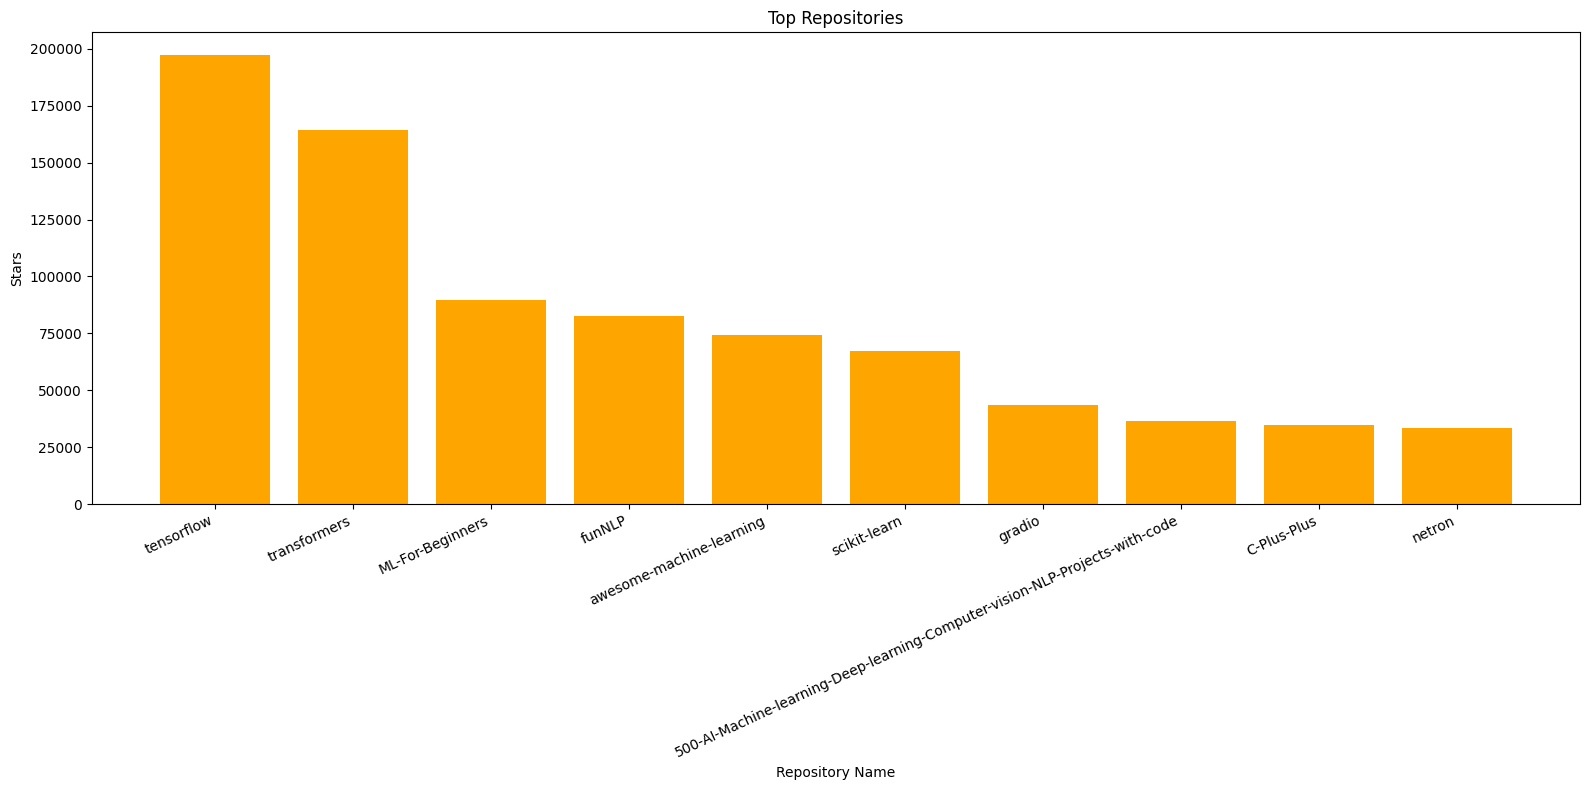

In [ ]:
plt.figure(figsize=(16, 8))
top10 = df_prepared.sort_values(by="stars", ascending=False).head(10)
plt.bar(top10["name"], top10["stars"], color="orange")
plt.title("Top Repositories")
plt.xlabel("Repository Name")
plt.ylabel("Stars")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

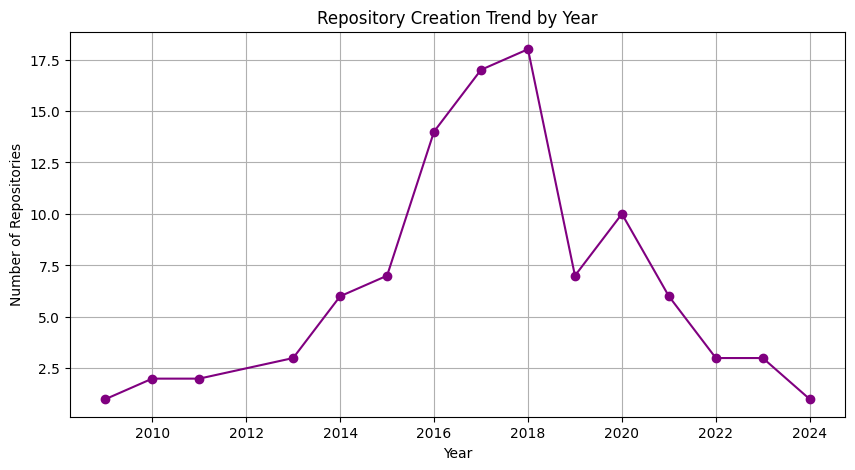

In [ ]:
df_prepared["year"] = pd.to_datetime(df_prepared["created_date"]).dt.year
yearly_counts = df_prepared.groupby("year").size()
plt.figure(figsize=(10, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker="o", color="purple")
plt.title("Repository Creation Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.grid(True)
plt.show()

###Step 8: Interpret Results
1. Important Patterns (Bar Chart)

Big Gap: tensorflow and transformers have many more stars than any other project.

AI Focus: Looking at the repository names, most top projects are about AI and Machine Learning.

2. Trends in the Data (Line Chart)

Peak Year: Project creation grew quickly and reached its highest point in 2018.

Drop Over Time: After 2018, people created fewer new projects every year.

 #### The Insights
Finding: tensorflow and transformers are the main leaders with the highest number of stars.

Meaning: Developers clearly prefer using a few well-known AI tools instead of spreading across many small ones.

Finding: Project creation grew fast until it peaked in 2018, then slowly went down.

Meaning: Most core open-source tools were created between 2016 and 2018, and now the market is mature.

Finding: Creating new projects has slowed down, while top existing projects keep getting more stars.

Meaning: It is better to use and support established top projects rather than wasting time building new ones from scratch.